# A Note
This notebook contains more EDA, as I discovered skewness and characteristics of variables *while* trying to transform them during the preprocessing step. I kept the EDA in this notebook for documentation, but in the future, I would check skew values during the initial exploration stage.

In [325]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

In [326]:
df = pd.read_csv('../data/online_shoppers_intention.csv')
df = df.drop(columns=['OperatingSystems', 'Browser', 'Region', 'Weekend'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  TrafficType              12330 non-null  int64  
 12  VisitorType              12330 non-null  str    
 13  Revenue                  12330 non-null  bool   
dtypes: bool(1), float64(7), int64(4),

In [327]:
df.shape

(12330, 14)

In [328]:
df = df[~((df['Administrative'] + df['Informational'] + df['ProductRelated']) == 0)]
df.shape

(12324, 14)

In [329]:
# Drop Traffic Types with session counts less than 100, and one hot encode the rest
threshold = 100
traffic_count= df['TrafficType'].value_counts()
len(traffic_count)


20

In [330]:
kept_traffic = traffic_count[traffic_count > threshold].index
len(kept_traffic)

11

In [331]:
kept_traffic

Index([2, 1, 3, 4, 13, 10, 6, 8, 5, 11, 20], dtype='int64', name='TrafficType')

In [332]:
df['TrafficType'] = df['TrafficType'].where(df['TrafficType'].isin(kept_traffic), 'Other')
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,TrafficType,VisitorType,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,Returning_Visitor,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,Returning_Visitor,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,3,Returning_Visitor,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,4,Returning_Visitor,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,4,Returning_Visitor,False


In [333]:
df_encoded = pd.get_dummies(df, columns=['TrafficType'], drop_first=True)
print(df_encoded.columns)

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'VisitorType', 'Revenue', 'TrafficType_2', 'TrafficType_3',
       'TrafficType_4', 'TrafficType_5', 'TrafficType_6', 'TrafficType_8',
       'TrafficType_10', 'TrafficType_11', 'TrafficType_13', 'TrafficType_20',
       'TrafficType_Other'],
      dtype='str')


Dummy variable TrafficType 1 was dropped to avoid redundancy.

In [334]:
df_encoded.shape

(12324, 24)

In [335]:
df_encoded['Month'].unique()

<StringArray>
['Feb', 'Mar', 'May', 'Oct', 'June', 'Jul', 'Aug', 'Nov', 'Sep', 'Dec']
Length: 10, dtype: str

In [336]:
df_encoded = pd.get_dummies(df_encoded, columns=['Month'], drop_first=True)
print(df_encoded.columns)

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'VisitorType',
       'Revenue', 'TrafficType_2', 'TrafficType_3', 'TrafficType_4',
       'TrafficType_5', 'TrafficType_6', 'TrafficType_8', 'TrafficType_10',
       'TrafficType_11', 'TrafficType_13', 'TrafficType_20',
       'TrafficType_Other', 'Month_Dec', 'Month_Feb', 'Month_Jul',
       'Month_June', 'Month_Mar', 'Month_May', 'Month_Nov', 'Month_Oct',
       'Month_Sep'],
      dtype='str')


In [337]:
df_encoded.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,TrafficType_Other,Month_Dec,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,False,False,True,False,False,False,False,False,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,False,False,True,False,False,False,False,False,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,False,False,True,False,False,False,False,False,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,False,False,True,False,False,False,False,False,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,False,False,True,False,False,False,False,False,False,False


The August dummy variable was dropped.

In [338]:
df_encoded.shape

(12324, 32)

In [339]:
df_encoded = pd.get_dummies(df_encoded, columns=['VisitorType'])
df_encoded = df_encoded.drop(columns=['VisitorType_Other']) # Hand pick 'VisitorType_Other' as the dummy variable to drop so that New_Visitor and Returning_Visitor are kept for their coefficients.
print(df_encoded.columns)

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Revenue',
       'TrafficType_2', 'TrafficType_3', 'TrafficType_4', 'TrafficType_5',
       'TrafficType_6', 'TrafficType_8', 'TrafficType_10', 'TrafficType_11',
       'TrafficType_13', 'TrafficType_20', 'TrafficType_Other', 'Month_Dec',
       'Month_Feb', 'Month_Jul', 'Month_June', 'Month_Mar', 'Month_May',
       'Month_Nov', 'Month_Oct', 'Month_Sep', 'VisitorType_New_Visitor',
       'VisitorType_Returning_Visitor'],
      dtype='str')


In [340]:
df_encoded['is_special_day'] = (df_encoded['SpecialDay'] > 0).astype(int)
df_encoded = df_encoded.drop(columns=['SpecialDay'])
df_encoded['is_special_day'].value_counts()

is_special_day
0    11073
1     1251
Name: count, dtype: int64

In [341]:
cols_skew_check = ['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues']

for col in cols_skew_check:
    print(f'{col}:, {df_encoded[col].skew()}')

Administrative_Duration:, 5.614588744779995
Informational_Duration:, 7.577322285353236
ProductRelated_Duration:, 7.262734883763103
BounceRates:, 2.9575417003709106
ExitRates:, 2.1531078894301925
PageValues:, 6.381432574576495


In [342]:
print("Skew Change")

for col in cols_skew_check:
    df_encoded[f'{col}_log'] = np.log1p(df_encoded[col])
    print(f'{col}_log:, {df_encoded[f'{col}_log'].skew()}')

Skew Change
Administrative_Duration_log:, 0.25443231124568577
Informational_Duration_log:, 1.9179162030007875
ProductRelated_Duration_log:, -1.4216896215061265
BounceRates_log:, 2.886668117788553
ExitRates_log:, 2.058944973217608
PageValues_log:, 1.8051523837119623


Administrative_Duration did well under a log transform.
Informational_Duration needs further inspection due to an insufficient decrease in skew (above 1).
ProductRelated_Duration went into a negative skew, likely due to the extreme outliers, which will need to be handled.
BounceRates and ExitRates showed a negligible change after log transform, and should be inspected.
PageValues decreased significantly, but needs to be further inspected (still above 1).

## Investigate Informational_Duration

In [343]:
(df_encoded['Informational_Duration'] == 0).mean()

np.float64(0.8048523206751055)

<Axes: >

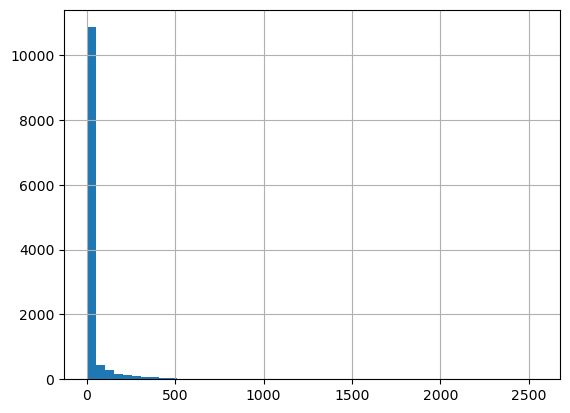

In [344]:
df_encoded['Informational_Duration'].hist(bins=50)

Informational_Duration has 0 values for 80% of the sessions, with which log transform did not sufficiently deal with.

Create an additional column to inform the model on whether informational pages were visited at all, keeping Informational_Duration_log to measure the effect of duration.

In [345]:
df_encoded['Visited_Informational'] = (df_encoded['Informational_Duration'] > 0).astype(int)

## Investigate ProductRelated_Duration

In [346]:
df_encoded['ProductRelated_Duration'].describe()

count    12324.000000
mean      1195.327888
std       1913.953467
min          0.000000
25%        184.575000
50%        599.216667
75%       1464.701335
max      63973.522230
Name: ProductRelated_Duration, dtype: float64

Extreme outliers are affecting the impact of a log transform.

In [347]:
# Check where the extremes are
df_encoded['ProductRelated_Duration'].quantile([.9, .95, .99, .999])

0.900     2880.043333
0.950     4303.007629
0.990     8701.289370
0.999    17400.599610
Name: ProductRelated_Duration, dtype: float64

The duration approximately doubles as the quantile increases between the chosen values.

In [348]:
df_encoded['ProductRelated_Duration'].sort_values(ascending=False).head(10)

8071    63973.52223
5152    43171.23338
9238    29970.46597
8784    27009.85943
8308    24844.15620
7662    23888.81000
6684    23342.08205
6165    23050.10414
5916    21857.04648
8972    21672.24425
Name: ProductRelated_Duration, dtype: float64

In [349]:
# The originally log transformed duration
df_encoded['ProductRelated_Duration_log'].skew()

np.float64(-1.4216896215061265)

In [350]:
# Try capping to the value at the 99.9th quantile, minimizing the affect to only 0.1% of the data
cap_value = df_encoded['ProductRelated_Duration'].quantile(.999)
df_encoded['ProductRelated_Duration_caped'] = df_encoded['ProductRelated_Duration'].clip(upper=cap_value)
df_encoded['ProductRelated_Duration_caped_log'] = np.log1p(df_encoded['ProductRelated_Duration_caped'])
df_encoded['ProductRelated_Duration_caped_log'].skew()

np.float64(-1.4253118120191648)

In [351]:
# Try capping to the value at the 99th quantile, minimizing the affect to only 1% of the data
cap_value = df_encoded['ProductRelated_Duration'].quantile(.99)
df_encoded['ProductRelated_Duration_caped'] = df_encoded['ProductRelated_Duration'].clip(upper=cap_value)
df_encoded['ProductRelated_Duration_caped_log'] = np.log1p(df_encoded['ProductRelated_Duration_caped'])
df_encoded['ProductRelated_Duration_caped_log'].skew()

np.float64(-1.442195981706159)

Capping before log transforming did not fix the skew, meaning the over correction during log transform isnt coming from the extreme outliers.

In [352]:
# Check the low end distribution instead
df_encoded['ProductRelated_Duration'].quantile([.01, .05, .10, .25])

0.01      0.000
0.05      0.000
0.10     36.000
0.25    184.575
Name: ProductRelated_Duration, dtype: float64

While the outliers reach ~64k seconds, 25% of the sessions have durations 184 seconds or under, with 5% of sessions at 0, which is hampering the effectiveness of log transform and capping. 

In [353]:
(df_encoded['ProductRelated_Duration'] == 0).mean()

np.float64(0.06077572216812723)

<Axes: >

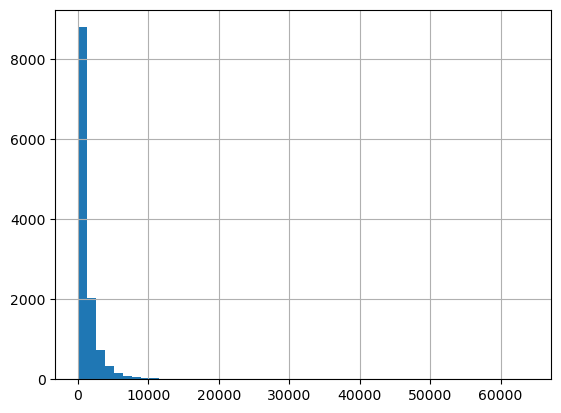

In [354]:
df_encoded['ProductRelated_Duration'].hist(bins=50)

In [355]:
# Try sqrt instead of log1p
df_encoded['ProductRelated_Duration_sqrt'] = np.sqrt(df_encoded['ProductRelated_Duration'])
print(df_encoded['ProductRelated_Duration_sqrt'].skew())

1.3947514763064561


The sqrt transformation more gently adjusted the feature's skew (7.26 -> 1.39), instead of the over-corrective log transformation (7.26 -> -1.42), which was attempted with and without capping with little effect.

<Axes: >

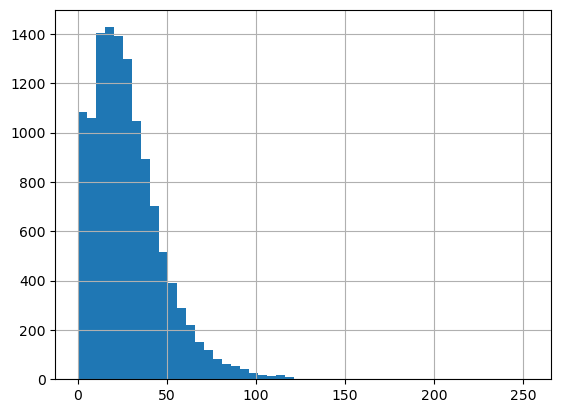

In [356]:
df_encoded['ProductRelated_Duration_sqrt'].hist(bins=50)

After the sqrt transformation, the column has a more normal distribution, and the right tail is less extreme.

In [357]:
df_encoded.info()

<class 'pandas.DataFrame'>
Index: 12324 entries, 0 to 12329
Data columns (total 43 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Administrative                     12324 non-null  int64  
 1   Administrative_Duration            12324 non-null  float64
 2   Informational                      12324 non-null  int64  
 3   Informational_Duration             12324 non-null  float64
 4   ProductRelated                     12324 non-null  int64  
 5   ProductRelated_Duration            12324 non-null  float64
 6   BounceRates                        12324 non-null  float64
 7   ExitRates                          12324 non-null  float64
 8   PageValues                         12324 non-null  float64
 9   Revenue                            12324 non-null  bool   
 10  TrafficType_2                      12324 non-null  bool   
 11  TrafficType_3                      12324 non-null  bool   
 12  Traffi

## Create Feature- Average Page Duration

Check for 0 values, which may impact results when dividing columns.

In [358]:
(df_encoded['ProductRelated_Duration'] == 0).sum()

np.int64(749)

In [359]:
(df_encoded['ProductRelated'] == 0).sum()

np.int64(32)

In [360]:
impossible = df_encoded[(df_encoded['ProductRelated'] ==0) & (df_encoded['ProductRelated_Duration'] != 0)]
print(len(impossible))

0


In [361]:
df_encoded['avg_product_duration'] = np.where(
    df_encoded['ProductRelated'] > 0,
    df_encoded['ProductRelated_Duration'] / df_encoded['ProductRelated'],
    0
)

print('NaN Check:')
print(df_encoded['avg_product_duration'].isna().sum())

print('Inf Check:')
print(np.isinf(df_encoded['avg_product_duration']).sum())

df_encoded['avg_product_duration'].describe()

NaN Check:
0
Inf Check:
0


count    12324.000000
mean        37.652012
std         44.771109
min          0.000000
25%         17.653428
50%         28.890721
75%         45.090227
max       1411.000000
Name: avg_product_duration, dtype: float64

In [362]:
df_encoded['avg_product_duration'].skew()

np.float64(10.296891486741623)

In [363]:
df_encoded['avg_product_duration_sqrt'] = np.sqrt(df_encoded['avg_product_duration'])
print(df_encoded['avg_product_duration_sqrt'].skew())

1.3034527198762373


In [364]:
(df_encoded['Administrative_Duration'] == 0).sum()

np.int64(5897)

In [365]:
(df_encoded['Administrative'] == 0).sum()

np.int64(5762)

In [366]:
impossible = df_encoded[(df_encoded['Administrative'] ==0) & df_encoded['Administrative_Duration'] != 0]
print(len(impossible))

0


In [367]:
df_encoded['avg_administrative_duration'] = np.where(
    df_encoded['Administrative'] > 0,
    df_encoded['Administrative_Duration'] / df_encoded['Administrative'],
    0
)

print('NaN Check:')
print(df_encoded['avg_administrative_duration'].isna().sum())

print('Inf Check:')
print(np.isinf(df_encoded['avg_administrative_duration']).sum())

df_encoded['avg_administrative_duration'].describe()

NaN Check:
0
Inf Check:
0


count    12324.000000
mean        20.206114
std         46.004590
min          0.000000
25%          0.000000
50%          5.137500
75%         24.375000
max       1566.600000
Name: avg_administrative_duration, dtype: float64

In [368]:
df_encoded['avg_administrative_duration'].skew()

np.float64(9.42265318425061)

In [369]:
df_encoded['avg_administrative_duration_log'] = np.log1p(df_encoded['avg_administrative_duration'])
print(df_encoded['avg_administrative_duration_log'].skew())

0.2915144117142232


In [370]:
(df_encoded['Informational_Duration'] == 0).sum()

np.int64(9919)

In [371]:
(df_encoded['Informational'] == 0).sum()

np.int64(9693)

In [372]:
impossible = df_encoded[(df_encoded['Informational'] ==0) & df_encoded['Informational_Duration'] != 0]
print(len(impossible))

0


In [373]:
df_encoded['avg_informational_duration'] = np.where(
    df_encoded['Informational'] > 0,
    df_encoded['Informational_Duration'] / df_encoded['Informational'],
    0
)

print('NaN Check:')
print(df_encoded['avg_informational_duration'].isna().sum())

print('Inf Check:')
print(np.isinf(df_encoded['avg_informational_duration']).sum())

df_encoded['avg_informational_duration'].describe()

NaN Check:
0
Inf Check:
0


count    12324.000000
mean        14.814970
std         65.566454
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       1778.000000
Name: avg_informational_duration, dtype: float64

In [374]:
df_encoded['avg_informational_duration'].skew()

np.float64(11.21572973322984)

In [375]:
df_encoded['avg_informational_duration_log'] = np.log1p(df_encoded['avg_informational_duration'])
print(df_encoded['avg_informational_duration_log'].skew())

1.9411074870992633


A note post-preprocessing - I created the average duration page view features thinking that the lasso technique will help pick the best feature amongst raw page counts and durations, but realized that because the average was mathematically derived from page count and total durations, the features will be highly correlated, and lasso will not handle these redundant columns well. I end up having to pick the feature that is best correlated with revenue- which is still a useful step that lets me identify whether averages are better predictors than the raw scores.

In [376]:
# For each associate page type, rank each feature's correlation to Revenue
groups = {
    'Administrative': ['Administrative', 'Administrative_Duration_log', 'avg_administrative_duration_log'],
    'Informational': ['Informational', 'Informational_Duration_log', 'avg_informational_duration_log'],
    'ProductRelated': ['ProductRelated', 'ProductRelated_Duration_sqrt', 'avg_product_duration_sqrt'],
}

for category, cols in groups.items():
    print(category)
    print(df_encoded[cols + ['Revenue']].corr()['Revenue'].drop('Revenue').sort_values(ascending=False))
    print()

Administrative
Administrative_Duration_log        0.166386
avg_administrative_duration_log    0.160742
Administrative                     0.138795
Name: Revenue, dtype: float64

Informational
Informational_Duration_log        0.112676
avg_informational_duration_log    0.111615
Informational                     0.095126
Name: Revenue, dtype: float64

ProductRelated
ProductRelated_Duration_sqrt    0.205144
ProductRelated                  0.158416
avg_product_duration_sqrt       0.107439
Name: Revenue, dtype: float64



It turns out that average per-page durations are actually less correlated with Revenue than the total duration columns for each page type- which consistently ranks higher.

In [377]:
df_encoded = df_encoded.drop(columns=[
    'avg_administrative_duration_log',
    'avg_informational_duration_log',
    'avg_product_duration_sqrt',
    'avg_informational_duration',
    'avg_administrative_duration',
    'avg_product_duration',
    'ProductRelated_Duration_caped', 
    'ProductRelated_Duration_caped_log', 
    'ProductRelated_Duration', 
    'ProductRelated_Duration_log', 
    'Administrative_Duration', 
    'Informational_Duration'
    ])
df_encoded.info()

<class 'pandas.DataFrame'>
Index: 12324 entries, 0 to 12329
Data columns (total 37 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Administrative                 12324 non-null  int64  
 1   Informational                  12324 non-null  int64  
 2   ProductRelated                 12324 non-null  int64  
 3   BounceRates                    12324 non-null  float64
 4   ExitRates                      12324 non-null  float64
 5   PageValues                     12324 non-null  float64
 6   Revenue                        12324 non-null  bool   
 7   TrafficType_2                  12324 non-null  bool   
 8   TrafficType_3                  12324 non-null  bool   
 9   TrafficType_4                  12324 non-null  bool   
 10  TrafficType_5                  12324 non-null  bool   
 11  TrafficType_6                  12324 non-null  bool   
 12  TrafficType_8                  12324 non-null  bool   
 13  Tr

## Investigate BounceRates

Skew change was minimal after log transforming (2.96 -> 2.89).

In [378]:
# Check unique values
df_encoded['BounceRates'].value_counts().sort_index()

BounceRates
0.000000    5518
0.000027       1
0.000034       1
0.000038       1
0.000039       1
            ... 
0.175000       1
0.176923       1
0.180000       4
0.183333       1
0.200000     695
Name: count, Length: 1872, dtype: int64

In [379]:
(df_encoded['BounceRates'] == 0).mean()

np.float64(0.4477442388834794)

44% of the sessions have bounce rates of 0- which means no compression happens for those rows at all. This is similar to how Informational_Duration was made of many 0 values (81%).

In [380]:
df_encoded['BounceRates'].nunique()

1872

There are still enough unique values in the column to not treat it as a categorical value.

In [381]:
# Create a column flagging the common 0 Bounce value for the model
df_encoded['has_bounce'] = (df_encoded['BounceRates'] > 0).astype(int)
df_encoded.info()

df_encoded = df_encoded.drop(columns=[
    'BounceRates_log'               # Leave the raw bounce rate, drop the log transformed column, as it did not decrease skew.
    ])

df_encoded.info()

<class 'pandas.DataFrame'>
Index: 12324 entries, 0 to 12329
Data columns (total 38 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Administrative                 12324 non-null  int64  
 1   Informational                  12324 non-null  int64  
 2   ProductRelated                 12324 non-null  int64  
 3   BounceRates                    12324 non-null  float64
 4   ExitRates                      12324 non-null  float64
 5   PageValues                     12324 non-null  float64
 6   Revenue                        12324 non-null  bool   
 7   TrafficType_2                  12324 non-null  bool   
 8   TrafficType_3                  12324 non-null  bool   
 9   TrafficType_4                  12324 non-null  bool   
 10  TrafficType_5                  12324 non-null  bool   
 11  TrafficType_6                  12324 non-null  bool   
 12  TrafficType_8                  12324 non-null  bool   
 13  Tr

## Investigate ExitRates
Skew change was minimal after log transforming (2.15 -> 2.06).

In [382]:
(df_encoded['ExitRates'] == 0).mean()

np.float64(0.006166828951639078)

In [383]:
df_encoded['ExitRates'].nunique()

4776

<Axes: >

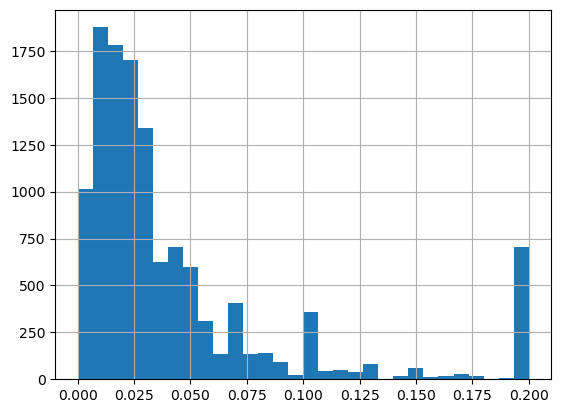

In [384]:
df_encoded['ExitRates'].hist(bins=30)

The seconds cluster near the end is what's causing the original skew.

In [385]:
# Check the characteristics of rows for the right-side peak
df_encoded[df_encoded['ExitRates'] > 0.18][['ExitRates', 'BounceRates', 'PageValues', 'ProductRelated', 'Administrative', 'Informational']].describe()

,ExitRates,BounceRates,PageValues,ProductRelated,Administrative,Informational
count,715.000000,715.000000,715.0,715.000000,715.000000,715.000000
mean,0.199809,0.196958,0.0,1.448951,0.020979,0.008392
std,0.001645,0.022298,0.0,1.281678,0.152869,0.091284
min,0.180342,0.000000,0.0,0.000000,0.000000,0.000000
25%,0.200000,0.200000,0.0,1.000000,0.000000,0.000000
50%,0.200000,0.200000,0.0,1.000000,0.000000,0.000000
75%,0.200000,0.200000,0.0,1.000000,0.000000,0.000000
max,0.200000,0.200000,0.0,13.000000,2.000000,1.000000


700 sessions- at least 75% of ExitRates and BounceRates are 0.20,
all have PageValues of 0,
50% only visited 1 product page, and
at least 75% visited 0 administrative and informational pages.

I conclude that 0.20 is a default bounce rate for sessions that showed low engagement, and very few total page views.

In [386]:
# Add a binary flag for sessions with high exit rates
df_encoded['high_exit_rate'] = (df_encoded['ExitRates'] >= 0.18).astype(int)
df_encoded = df_encoded.drop(columns=['ExitRates_log'])   # Drop the log transformed column created in the beginning
df_encoded.info()

<class 'pandas.DataFrame'>
Index: 12324 entries, 0 to 12329
Data columns (total 37 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Administrative                 12324 non-null  int64  
 1   Informational                  12324 non-null  int64  
 2   ProductRelated                 12324 non-null  int64  
 3   BounceRates                    12324 non-null  float64
 4   ExitRates                      12324 non-null  float64
 5   PageValues                     12324 non-null  float64
 6   Revenue                        12324 non-null  bool   
 7   TrafficType_2                  12324 non-null  bool   
 8   TrafficType_3                  12324 non-null  bool   
 9   TrafficType_4                  12324 non-null  bool   
 10  TrafficType_5                  12324 non-null  bool   
 11  TrafficType_6                  12324 non-null  bool   
 12  TrafficType_8                  12324 non-null  bool   
 13  Tr

## Investigate Page Values
Huge improvement from a skew of 6.38 to 1.80 after a log transform.

In [387]:
(df_encoded['PageValues'] == 0).mean()

np.float64(0.7784810126582279)

With 77% of sessions having PageValues of 0, a binary flag for 'has_page_value' would be valuable.
Keep the continuous, log transformed PageValue column to keep information on the other 23% of rows.

In [388]:
df_encoded['has_page_value'] = (df_encoded['PageValues'] > 0).astype(int)
df_encoded = df_encoded.drop(columns=['PageValues'])
df_encoded.info()

<class 'pandas.DataFrame'>
Index: 12324 entries, 0 to 12329
Data columns (total 37 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Administrative                 12324 non-null  int64  
 1   Informational                  12324 non-null  int64  
 2   ProductRelated                 12324 non-null  int64  
 3   BounceRates                    12324 non-null  float64
 4   ExitRates                      12324 non-null  float64
 5   Revenue                        12324 non-null  bool   
 6   TrafficType_2                  12324 non-null  bool   
 7   TrafficType_3                  12324 non-null  bool   
 8   TrafficType_4                  12324 non-null  bool   
 9   TrafficType_5                  12324 non-null  bool   
 10  TrafficType_6                  12324 non-null  bool   
 11  TrafficType_8                  12324 non-null  bool   
 12  TrafficType_10                 12324 non-null  bool   
 13  Tr

In [389]:
# Check redundancy from correlation across the whole feature set
X = df_encoded.drop(columns=['Revenue']).astype(float)
X_const = sm.add_constant(X)

vif = pd.DataFrame({
    'feature': X_const.columns,
    'VIF': [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
}).sort_values('VIF', ascending=False)

vif = vif[vif['feature'] != 'const']
print(vif)

                          feature        VIF
27  VisitorType_Returning_Visitor  21.894217
26        VisitorType_New_Visitor  21.821611
4                     BounceRates  14.649823
30     Informational_Duration_log  12.122521
32          Visited_Informational   9.380342
36                 has_page_value   8.406103
5                       ExitRates   7.969158
31                 PageValues_log   7.762852
22                      Month_May   6.861512
35                 high_exit_rate   6.653840
23                      Month_Nov   6.276440
21                      Month_Mar   4.788274
17                      Month_Dec   4.507907
33   ProductRelated_Duration_sqrt   4.296592
3                  ProductRelated   3.487726
2                   Informational   3.274652
29    Administrative_Duration_log   2.971192
1                  Administrative   2.942644
24                      Month_Oct   2.193673
6                   TrafficType_2   2.048096
25                      Month_Sep   1.968402
34        

After one hot encoding and dropping the rare 'VisitorType_Other' category, New_Visitor is about equal to 1 - Returning Visitor, because 'VisitorType_Other' is a rare category with only 85 rows.

To fix the highly correlated new and returning visitor columns I previously created, returning visitors which make up 10551 rows will be dropped and made the baseline alongside 'VisitorType_Other' against which the new visitor feature will be compared. 

In [390]:
df_encoded = df_encoded.drop(columns=['VisitorType_Returning_Visitor'])

In [391]:
X = df_encoded.drop(columns=['Revenue']).astype(float)
X_const = sm.add_constant(X)

vif = pd.DataFrame({
    'feature': X_const.columns,
    'VIF': [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
}).sort_values('VIF', ascending=False)

vif = vif[vif['feature'] != 'const']
print(vif)

                         feature        VIF
4                    BounceRates  14.649220
29    Informational_Duration_log  12.122224
31         Visited_Informational   9.379931
35                has_page_value   8.402799
5                      ExitRates   7.967812
30                PageValues_log   7.759195
22                     Month_May   6.861511
34                high_exit_rate   6.651874
23                     Month_Nov   6.275090
21                     Month_Mar   4.788236
17                     Month_Dec   4.491509
32  ProductRelated_Duration_sqrt   4.296412
3                 ProductRelated   3.487601
2                  Informational   3.274649
28   Administrative_Duration_log   2.970937
1                 Administrative   2.942643
24                     Month_Oct   2.191862
6                  TrafficType_2   2.048096
25                     Month_Sep   1.968360
33                    has_bounce   1.947761
19                     Month_Jul   1.934541
20                    Month_June

From my EDA notebook, I already know that BounceRates and ExitRates are highly correlated, and one of them needs to be dropped.

In [392]:
# Check correlations with Revenue to pick a feature to drop
df_encoded[['BounceRates', 'ExitRates', 'Revenue']].corr()['Revenue']

BounceRates   -0.150406
ExitRates     -0.206927
Revenue        1.000000
Name: Revenue, dtype: float64

ExitRates is more highly correlated with Revenue, thus BounceRates will be dropped.

In [393]:
df_encoded = df_encoded.drop(columns=['BounceRates'])

In [394]:
X = df_encoded.drop(columns=['Revenue']).astype(float)
X_const = sm.add_constant(X)

vif = pd.DataFrame({
    'feature': X_const.columns,
    'VIF': [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
}).sort_values('VIF', ascending=False)

vif = vif[vif['feature'] != 'const']
print(vif)

                         feature        VIF
28    Informational_Duration_log  12.121096
30         Visited_Informational   9.379606
34                has_page_value   8.384375
29                PageValues_log   7.728783
21                     Month_May   6.861344
22                     Month_Nov   6.272528
20                     Month_Mar   4.786916
4                      ExitRates   4.768433
16                     Month_Dec   4.489455
31  ProductRelated_Duration_sqrt   4.294988
3                 ProductRelated   3.486254
2                  Informational   3.272760
33                high_exit_rate   3.167551
27   Administrative_Duration_log   2.961510
1                 Administrative   2.940887
23                     Month_Oct   2.191807
5                  TrafficType_2   2.047626
24                     Month_Sep   1.968341
18                     Month_Jul   1.934541
19                    Month_June   1.635708
6                  TrafficType_3   1.603878
32                    has_bounce

In [395]:
df_encoded[['Informational_Duration_log', 'Visited_Informational']].corr()

,Informational_Duration_log,Visited_Informational
Informational_Duration_log,1.000000,0.944333
Visited_Informational,0.944333,1.000000


These variables carry nearly the same information, since Visited_informational is derived from 'Informational_Duration' (Informational_Duration_log > 0). One of them needs to be dropped.

In [396]:
df_encoded[['Informational_Duration_log', 'Visited_Informational', 'Revenue']].corr()['Revenue']

Informational_Duration_log    0.112676
Visited_Informational         0.109046
Revenue                       1.000000
Name: Revenue, dtype: float64

Nearly 80% of Informational_Duration was a value of 0, which is why the feature Visited_Informational was created. Since both of the columns' correlation with revenue is similar, and the binary of Visited_Informational is more easily interpretable than the log of informational page duration, I'll keep the 'Visited_Informational' column.

In [397]:
df_encoded = df_encoded.drop(columns=['Informational_Duration_log'])

X = df_encoded.drop(columns=['Revenue']).astype(float)
X_const = sm.add_constant(X)

vif = pd.DataFrame({
    'feature': X_const.columns,
    'VIF': [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
}).sort_values('VIF', ascending=False)

vif = vif[vif['feature'] != 'const']
print(vif)

                         feature       VIF
33                has_page_value  8.378078
28                PageValues_log  7.727675
21                     Month_May  6.859214
22                     Month_Nov  6.270412
20                     Month_Mar  4.786912
4                      ExitRates  4.767772
16                     Month_Dec  4.488812
30  ProductRelated_Duration_sqrt  4.289844
3                 ProductRelated  3.484648
32                high_exit_rate  3.167410
27   Administrative_Duration_log  2.961193
1                 Administrative  2.938521
2                  Informational  2.575571
29         Visited_Informational  2.552701
23                     Month_Oct  2.191685
5                  TrafficType_2  2.045962
24                     Month_Sep  1.967772
18                     Month_Jul  1.934431
19                    Month_June  1.634444
6                  TrafficType_3  1.603875
31                    has_bounce  1.555899
7                  TrafficType_4  1.516373
17         

In [398]:
df_encoded[['has_page_value', 'PageValues_log']].corr()

,has_page_value,PageValues_log
has_page_value,1.000000,0.923171
PageValues_log,0.923171,1.000000


Similarly to the informational related columns, 'has_page_value' was derived from 'PageValues', and is too highly correlated with it, meaning one needs to be dropped.

In [399]:
df_encoded[['has_page_value', 'PageValues_log', 'Revenue']].corr()['Revenue']

has_page_value    0.602475
PageValues_log    0.635032
Revenue           1.000000
Name: Revenue, dtype: float64

In [400]:
# has_page_values is dropped due to a slightly lower correlation with Revenue, 
# and by itself does not do a better job than the original continuous value column it was derived from.
df_encoded = df_encoded.drop(columns=['has_page_value'])

Editing note: This choice is inconsistent with the way I handled picking an informational-related column above. I kept 'Visited_Informational' because it's more interpretable than a log duration, while still being similarly correlated to 'Revenue'.
while in this case I chose to keep 'PageValues_log', even thought its correlation to 'Revenue' is only 3 points higher.

In [401]:
X = df_encoded.drop(columns=['Revenue']).astype(float)
X_const = sm.add_constant(X)

vif = pd.DataFrame({
    'feature': X_const.columns,
    'VIF': [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
}).sort_values('VIF', ascending=False)

vif = vif[vif['feature'] != 'const']
print(vif)

                         feature       VIF
21                     Month_May  6.859212
22                     Month_Nov  6.266127
20                     Month_Mar  4.786357
4                      ExitRates  4.761565
16                     Month_Dec  4.486129
30  ProductRelated_Duration_sqrt  4.276032
3                 ProductRelated  3.440047
32                high_exit_rate  3.166817
27   Administrative_Duration_log  2.961177
1                 Administrative  2.888157
2                  Informational  2.574543
29         Visited_Informational  2.551364
23                     Month_Oct  2.191651
5                  TrafficType_2  2.044542
24                     Month_Sep  1.967767
18                     Month_Jul  1.934038
19                    Month_June  1.634435
6                  TrafficType_3  1.602845
31                    has_bounce  1.555034
7                  TrafficType_4  1.515842
17                     Month_Feb  1.479834
26                is_special_day  1.440361
25       Vi

The previous multicollinearity issue in the dataset has been drastically improved on.

In [402]:
# df_encoded[['high_exit_rate', 'ExitRates']].corr()

Edit note: Reinspecting the VIF, ExitRates is high on the list. I did not inspect the correlation between 'high_exit_rate' and 'ExitRates', and this is something I'd implement in a preprocessing_v3.ipynb notebook, picking a column to drop.

In [403]:
df_encoded.info()

<class 'pandas.DataFrame'>
Index: 12324 entries, 0 to 12329
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Administrative                12324 non-null  int64  
 1   Informational                 12324 non-null  int64  
 2   ProductRelated                12324 non-null  int64  
 3   ExitRates                     12324 non-null  float64
 4   Revenue                       12324 non-null  bool   
 5   TrafficType_2                 12324 non-null  bool   
 6   TrafficType_3                 12324 non-null  bool   
 7   TrafficType_4                 12324 non-null  bool   
 8   TrafficType_5                 12324 non-null  bool   
 9   TrafficType_6                 12324 non-null  bool   
 10  TrafficType_8                 12324 non-null  bool   
 11  TrafficType_10                12324 non-null  bool   
 12  TrafficType_11                12324 non-null  bool   
 13  TrafficType_13   

In [404]:
df_encoded.to_csv('../data/clean_online_shoppers_dataset.csv', index=False)